In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/failure_ml_dataset.csv",
    parse_dates=["snapshot_date"]
)

print(df.shape)
df.head()

(91000, 14)


,asset_id,section_id,department,asset_type,snapshot_date,asset_age_years,condition_score,criticality,usage_factor,weather_stress,historical_failure_count,historical_downtime_hours,days_since_last_failure,failure_within_30_days
0,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-01-01,8,93.126212,6,0.565548,0.416271,0,0.0,NaN,0
1,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-02-01,8,92.456850,6,0.565548,0.087173,0,0.0,NaN,0
2,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-03-01,8,95.602455,6,0.565548,0.899679,0,0.0,NaN,0
3,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-04-01,8,96.610857,6,0.565548,0.408667,0,0.0,NaN,0
4,ASSET00001,RTM-VAD-01,TRACTION,OHE,2019-05-01,8,94.519420,6,0.565548,0.391072,0,0.0,NaN,0


In [2]:
df["condition_risk"] = (
    100 - df["condition_score"]
) / 100

In [3]:
df["age_risk"] = (
    df["asset_age_years"] / 30
).clip(0, 1)

In [4]:
df["failure_history_risk"] = (
    df["historical_failure_count"] / 5
).clip(0, 1)

In [5]:
df["criticality_risk"] = (
    df["criticality"] - 5
) / 5

In [6]:
df["usage_risk"] = (
    df["usage_factor"] / 1.5
).clip(0, 1)

In [7]:
df["weather_risk"] = df["weather_stress"].clip(0, 1)

In [8]:
df["risk_score"] = (
    0.30 * df["condition_risk"] +
    0.15 * df["age_risk"] +
    0.20 * df["failure_history_risk"] +
    0.20 * df["criticality_risk"] +
    0.10 * df["usage_risk"] +
    0.05 * df["weather_risk"]
)

In [9]:
def risk_category(score):
    if score >= 0.75:
        return "CRITICAL"
    elif score >= 0.50:
        return "HIGH"
    elif score >= 0.25:
        return "MEDIUM"
    else:
        return "LOW"

In [10]:
df["risk_category"] = df["risk_score"].apply(
    risk_category
)

In [11]:
df["risk_category"].value_counts()

risk_category
MEDIUM    60547
LOW       27261
HIGH       3192
Name: count, dtype: int64

In [12]:
df[
    [
        "asset_id",
        "section_id",
        "department",
        "asset_type",
        "condition_score",
        "asset_age_years",
        "criticality",
        "historical_failure_count",
        "risk_score",
        "risk_category"
    ]
].sort_values(
    "risk_score",
    ascending=False
).head(20)

,asset_id,section_id,department,asset_type,condition_score,asset_age_years,criticality,historical_failure_count,risk_score,risk_category
54775,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,65.684592,20,10,5,0.740180,HIGH
54772,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,67.839689,19,10,5,0.739913,HIGH
54771,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,68.239406,19,10,5,0.739630,HIGH
58232,ASSET00640,MTJ-AGC-01,S&T,POINT_MACHINE,59.892322,17,10,5,0.713461,HIGH
58234,ASSET00640,MTJ-AGC-01,S&T,POINT_MACHINE,56.445107,18,10,5,0.709703,HIGH
54774,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,71.459262,19,10,5,0.707206,HIGH
58222,ASSET00640,MTJ-AGC-01,S&T,POINT_MACHINE,59.136104,17,10,5,0.702241,HIGH
54781,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,68.112607,20,10,5,0.702010,HIGH
58225,ASSET00640,MTJ-AGC-01,S&T,POINT_MACHINE,61.686696,17,10,5,0.698048,HIGH
54773,ASSET00602,BPL-RTM-01,S&T,AXLE_COUNTER,79.992397,19,10,5,0.697023,HIGH


In [13]:
risk_performance = (
    df.groupby("risk_category")[
        "failure_within_30_days"
    ]
    .agg(
        failure_rate="mean",
        samples="count",
        failures="sum"
    )
    .reset_index()
)

risk_performance

,risk_category,failure_rate,samples,failures
0,HIGH,0.011905,3192,38
1,LOW,0.002531,27261,69
2,MEDIUM,0.005236,60547,317


In [14]:
df.groupby(
    "failure_within_30_days"
)["risk_score"].mean()

failure_within_30_days
0    0.308815
1    0.352832
Name: risk_score, dtype: float64

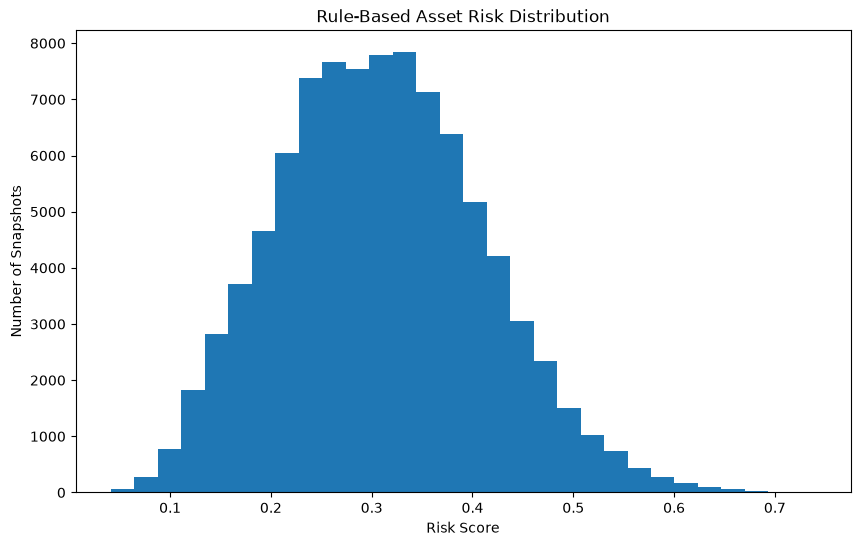

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df["risk_score"],
    bins=30
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Snapshots")
plt.title("Rule-Based Asset Risk Distribution")

plt.show()

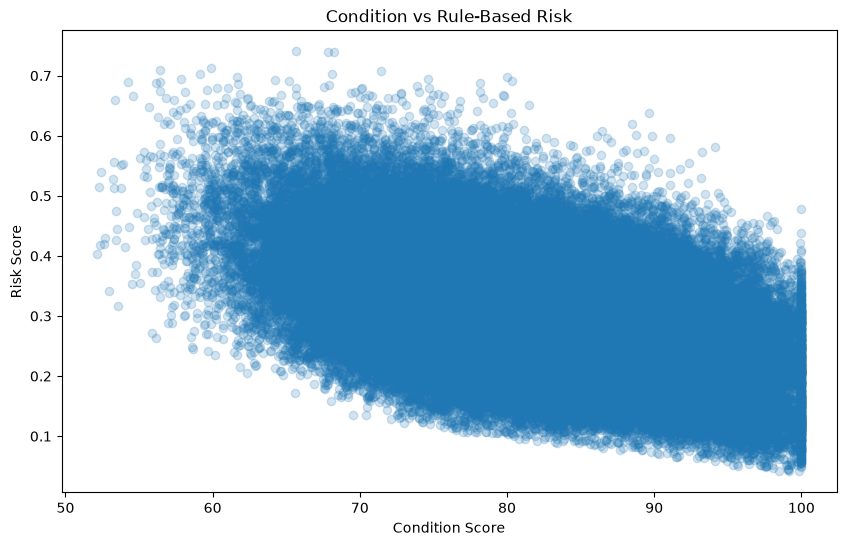

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["condition_score"],
    df["risk_score"],
    alpha=0.2
)

plt.xlabel("Condition Score")
plt.ylabel("Risk Score")
plt.title("Condition vs Rule-Based Risk")

plt.show()

In [17]:
df["baseline_prediction"] = (
    df["risk_score"] >= 0.50
).astype(int)

In [18]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

y_true = df["failure_within_30_days"]
y_pred = df["baseline_prediction"]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy : 0.9610989010989011
Precision: 0.011904761904761904
Recall   : 0.08962264150943396
F1 Score : 0.02101769911504425

Confusion Matrix:
[[87422  3154]
 [  386    38]]


In [19]:
def calculate_risk(data):
    
    data = data.copy()
    
    data["condition_risk"] = (
        100 - data["condition_score"]
    ) / 100
    
    data["age_risk"] = (
        data["asset_age_years"] / 30
    ).clip(0, 1)
    
    data["failure_history_risk"] = (
        data["historical_failure_count"] / 5
    ).clip(0, 1)
    
    data["criticality_risk"] = (
        data["criticality"] - 5
    ) / 5
    
    data["usage_risk"] = (
        data["usage_factor"] / 1.5
    ).clip(0, 1)
    
    data["weather_risk"] = (
        data["weather_stress"]
    ).clip(0, 1)
    
    data["risk_score"] = (
        0.30 * data["condition_risk"] +
        0.15 * data["age_risk"] +
        0.20 * data["failure_history_risk"] +
        0.20 * data["criticality_risk"] +
        0.10 * data["usage_risk"] +
        0.05 * data["weather_risk"]
    )
    
    data["baseline_prediction"] = (
        data["risk_score"] >= 0.50
    ).astype(int)
    
    return data

In [20]:
import pandas as pd

# Load the ML dataset
df = pd.read_csv(
    "../data/processed/failure_ml_dataset.csv",
    parse_dates=["snapshot_date"]
)

# Create training set
train = df[
    df["snapshot_date"] < "2025-01-01"
].copy()

# Create validation set
validation = df[
    (df["snapshot_date"] >= "2025-01-01") &
    (df["snapshot_date"] < "2026-01-01")
].copy()

# Create test set
test = df[
    df["snapshot_date"] >= "2026-01-01"
].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (72000, 14)
Validation: (12000, 14)
Test: (7000, 14)


In [21]:
test_baseline = calculate_risk(test)

print(
    "Test_samples:",
    len(test_baseline)
)

Test_samples: 7000


In [22]:
test_baseline = calculate_risk(test)

In [23]:
test_baseline = calculate_risk(test)

print(
    "Test samples:",
    len(test_baseline)
)

Test samples: 7000


In [24]:
y_true = test_baseline["failure_within_30_days"]
y_pred = test_baseline["baseline_prediction"]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))


Accuracy : 0.8992857142857142
Precision: 0.021961932650073207
Recall   : 0.28846153846153844
F1 Score : 0.04081632653061224


In [25]:
test_baseline.to_csv(
    "../data/predictions/baseline_risk_predictions.csv",
    index=False
)

In [26]:
import os

os.makedirs(
    "../data/predictions",
    exist_ok=True
)